<a href="https://colab.research.google.com/github/edvaldomanuel0-create/edvaldo/blob/main/U3_A4_VISUALIZACAO_DE_DADOS_EM_PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- PRIMEIRAS LINHAS DO DATAFRAME ---
   id_venda data_venda    produto    categoria  valor_venda
0        29 2023-01-01  Produto A  Eletrônicos       1500.0
1        30 2023-01-05  Produto B       Roupas        350.0
2        31 2023-02-10  Produto C  Eletrônicos       1200.0
3        32 2023-03-15  Produto D       Livros        200.0
4        33 2023-03-20  Produto E  Eletrônicos        800.0

--- INFORMAÇÕES DO DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     14 non-null     int64         
 1   data_venda   14 non-null     datetime64[ns]
 2   produto      14 non-null     object        
 3   categoria    14 non-null     object        
 4   valor_venda  14 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 692.0+ bytes
None

--- TOTAL DE VENDAS POR CATEGOR

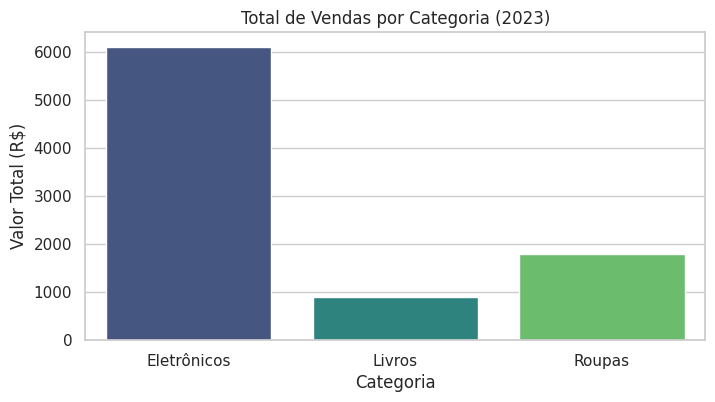

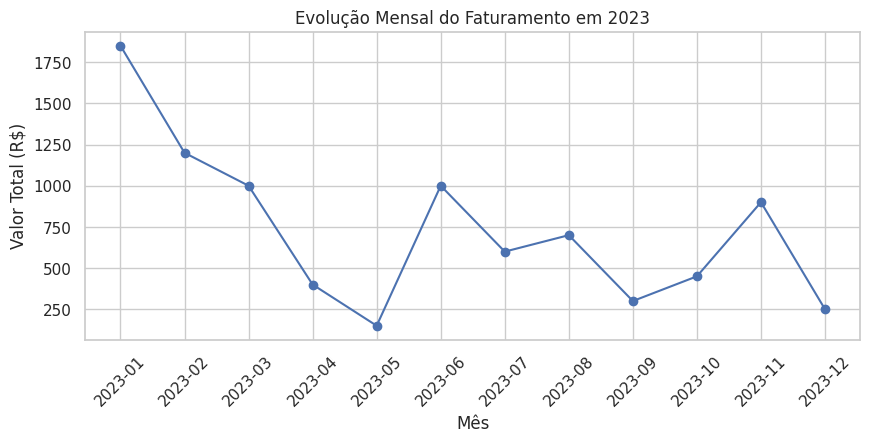

In [3]:
# ============================================================
# EXPERIMENTO: MELHORAR O DESEMPENHO DE VENDAS
# Disciplina: Linguagem de Programação
# Unidade: U3_INTRODUÇÃO_A_ANÁLISE_DE_DADOS_COM_PYTHON
# Aula: A4_VISUALIZAÇÃO_DE_DADOS_EM_PYTHON
# ============================================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Passo 1: Conectar ao banco de dados SQLite e criar a tabela
# ------------------------------------------------------------
conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()

# Criar a tabela vendas1
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')

# Limpar dados de execuções anteriores e inserir novos registros
cursor.execute('DELETE FROM vendas1')
cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00);
''')
conexao.commit()

# ------------------------------------------------------------
# Passo 2: Explorar e preparar os dados
# ------------------------------------------------------------
# Carregar dados do banco para um DataFrame Pandas
query = "SELECT * FROM vendas1"
df_vendas = pd.read_sql_query(query, conexao)

# Converter a coluna data_venda para o tipo datetime
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

print("--- PRIMEIRAS LINHAS DO DATAFRAME ---")
print(df_vendas.head())
print("\n--- INFORMAÇÕES DO DATAFRAME ---")
print(df_vendas.info())

# ------------------------------------------------------------
# Passo 3: Análise dos dados
# ------------------------------------------------------------
# Agrupar vendas por categoria
vendas_categoria = df_vendas.groupby('categoria')['valor_venda'].sum().reset_index()

# Agrupamento mensal para análise de tendência
df_vendas['mes'] = df_vendas['data_venda'].dt.to_period('M')
vendas_mensais = df_vendas.groupby('mes')['valor_venda'].sum().reset_index()
vendas_mensais['mes'] = vendas_mensais['mes'].astype(str)

print("\n--- TOTAL DE VENDAS POR CATEGORIA ---")
print(vendas_categoria)

# ------------------------------------------------------------
# Passo 4: Visualização dos dados
# ------------------------------------------------------------
sns.set_theme(style="whitegrid")

# Gráfico 1: Vendas por Categoria (Seaborn Barplot atualizado)
plt.figure(figsize=(8, 4))
sns.barplot(
    data=vendas_categoria,
    x='categoria',
    y='valor_venda',
    hue='categoria',
    legend=False,
    palette='viridis'
)
plt.title('Total de Vendas por Categoria (2023)')
plt.xlabel('Categoria')
plt.ylabel('Valor Total (R$)')
plt.show()

# Gráfico 2: Evolução Mensal das Vendas (Matplotlib Lineplot)
plt.figure(figsize=(10, 4))
plt.plot(vendas_mensais['mes'], vendas_mensais['valor_venda'], marker='o', color='b', linestyle='-')
plt.title('Evolução Mensal do Faturamento em 2023')
plt.xlabel('Mês')
plt.ylabel('Valor Total (R$)')
plt.xticks(rotation=45)
plt.show()

# ------------------------------------------------------------
# Passo 5: Fechar conexão
# ------------------------------------------------------------
conexao.close()